# Machine Learning 0 - Introduction

In this lab, we will introduce the classification problem that we will be working on for the last three labs. The objectives of the lab are:

* Examine the dataset and prepare the basic pipeline that will be used in the next lab.
* Make sure that we use a correct methodology for comparing the algorithms
* Get used to working with the [scikit-learn](https://scikit-learn.org/stable/) library.

## Important note

For the machine learning labs, **each student must write a report** (one report for all labs together) which will be used during the oral exam. This report should highlight the different methods used during the labs, but also how you validated each method and compared their results.

## Introduction to the dataset

The [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) dataset has been collected by Alex Krizhevsky, Vinod Nair, and Geoffrey Hinton. It consists of 60.000 32x32 colour images, split in 10 classes: 'airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'.

*Reference: Learning Multiple Layers of Features from Tiny Images, Alex Krizhevsky, 2009.* PDF available at https://www.cs.toronto.edu/~kriz/learning-features-2009-TR.pdf

For the purpose of the INFO-H-501 laboratories, we will use a subset of those images by only taking 3 different classes: 'airplane', 'bird' and 'horse'.

[Click here to download](https://my.pcloud.com/publink/show?code=XZJUCPkZqiVxqtn8CXRB7D78YKt88RJvzWyk) the modified dataset. Extract the ZIP file and put the CIFAR10 folder in the same directory as the notebook.

The images are 32x32 8-bit **RGB**, and from these we extracted **Histogram of Gradient** vectors (16 orientations x 16 blocks = 256 values in HoG vector).

The following code pre-loads all of this data (make sure that you have the [lab_tools.py](https://github.com/odebeir/info-h-500-501/blob/master/LABS1/lab_tools.py) file in the same directory as the notebook, if you didn't clone the repository):

In [1]:
from lab_tools import CIFAR10, get_hog_image

Pre-loading training data
Pre-loading test data


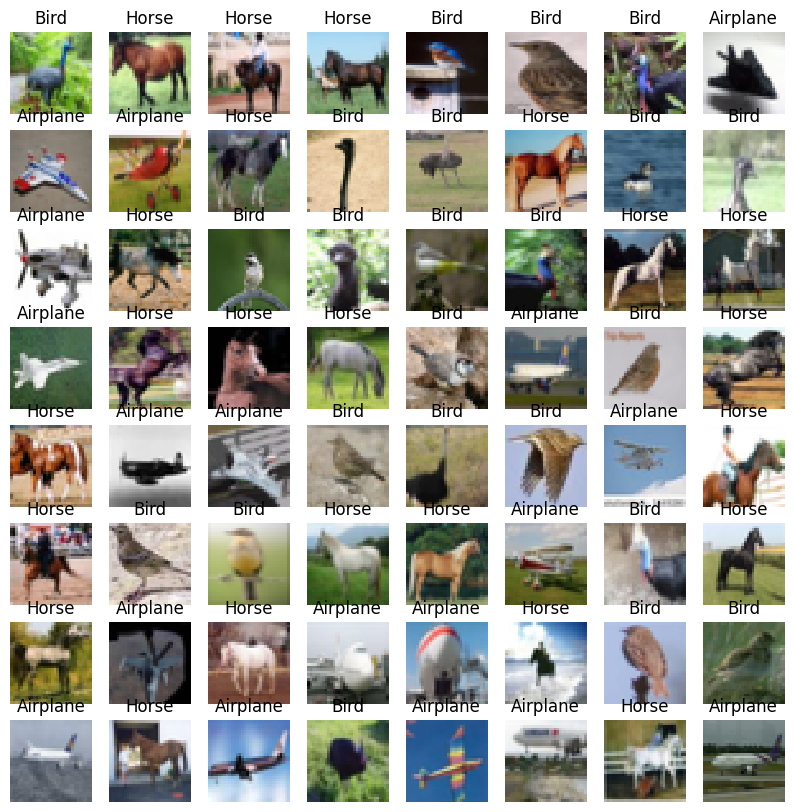

In [2]:
dataset = CIFAR10('./CIFAR10')
from matplotlib import pyplot as plt
%matplotlib inline

plt.figure(figsize=(10,10))
for i in range(64):
    plt.subplot(8,8,i+1)
    plt.imshow(dataset.train['images'][i].reshape((32,32,3)), interpolation='none')
    plt.title(dataset.labels[dataset.train['labels'][i]])
    plt.axis('off')
plt.show()

We can also have a look at some HoG images:

- images_hog : refers to a common variable name used in machine learning workflows, specifically for Histogram of Oriented Gradients (HOG) features extracted from test images. 

- Feature Extraction for SVMs: HOG is often used in combination with Support Vector Machines (SVMs) to detect objects (e.g., lower-body detection).


Gradient Computation: The image is analyzed to find horizontal (
) and vertical (
) changes in brightness. For every pixel, the algorithm calculates a gradient magnitude (how sharp the change is) and an orientation (the direction of that change).
Cell Division: The image is divided into small, connected regions called cells (typically 8x8 pixels).
Orientation Histograms: For each cell, a histogram is created. It usually has 9 bins covering 0 to 180 degrees. Each pixel in the cell "votes" for a bin based on its orientation, with the weight of the vote determined by its magnitude.




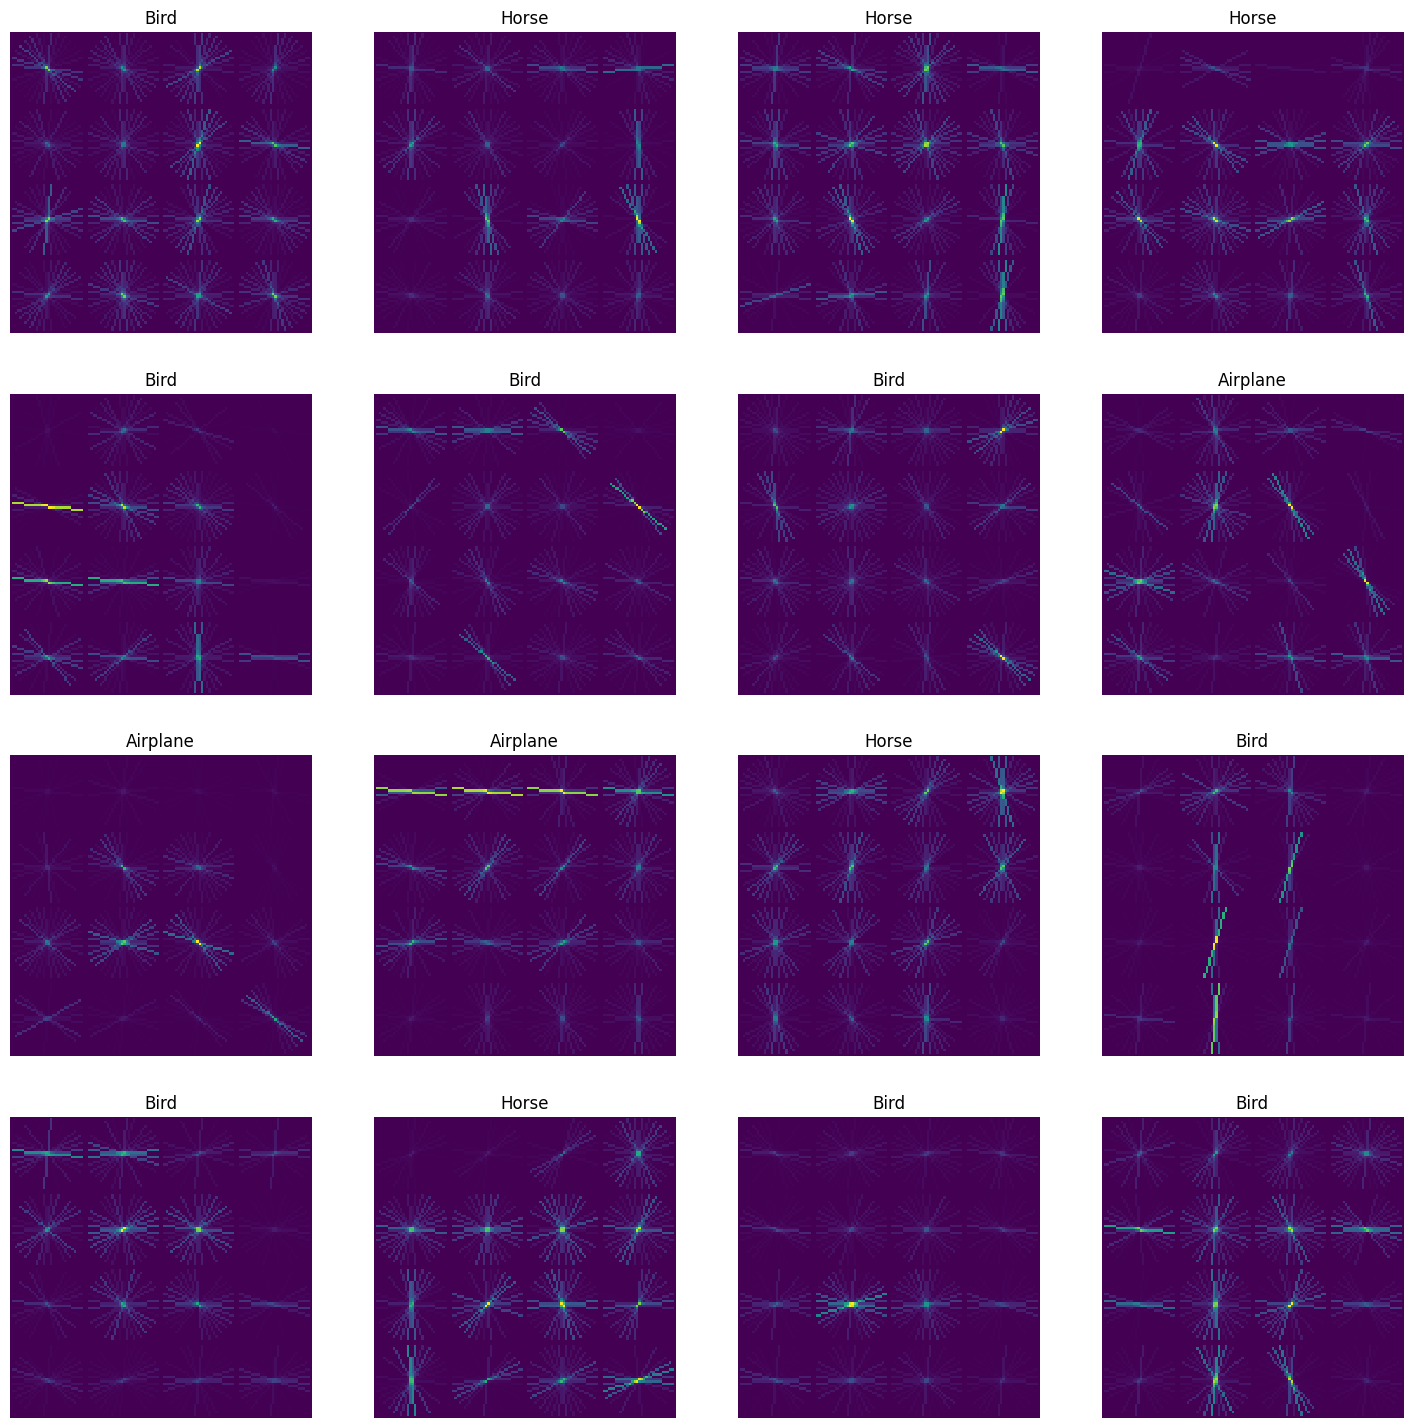

In [3]:
plt.figure(figsize=(18,18))
for i in range(16):
    plt.subplot(4,4,i+1) 
    hog = dataset.train['hog'][i].reshape((4,4,16))
    plt.imshow(get_hog_image(hog, 128), interpolation='none')
    plt.title(dataset.labels[dataset.train['labels'][i]])
    plt.axis('off')
plt.show()

Note that this is an "image" representation of the HoG, but that the actual data that we will be working on is a size 256 vector for each image. Our **feature space** has therefore 256 dimensions. 

## Exploring the dataset

The *dataset* object gives you access to different attributes:

* *dataset.path* contains the path to the CIFAR10 folder.
* *dataset.labels* contains the name of the three classes
* *dataset.train* and *dataset.test* are dictionaries containing three numpy arrays each:
    * *images* contains the RGB images
    * *hog* contains the HoG vectors
    * *labels* contains the label for each image

In [4]:
print(dataset.path)
print(dataset.labels)
print(dataset.train.keys())
print(dataset.train['hog'].shape)

./CIFAR10
['Airplane', 'Bird', 'Horse']
dict_keys(['images', 'hog', 'labels'])
(15000, 256)


### Quick questions:

The dataset has already been split into a training set (dataset.train) and a test set (dataset.test).

* How many images are in the training set ?
* How many images are in the test set ?
* What is the class distribution of the dataset ?

In [5]:
import numpy as np

# Number of images
n_train = len(dataset.train['images'])
n_test = len(dataset.test['images'])

print("Number of training images:", n_train)
print("Number of test images:", n_test)

# Class counts in each split
train_counts = np.bincount(dataset.train['labels'], minlength=len(dataset.labels))
test_counts = np.bincount(dataset.test['labels'], minlength=len(dataset.labels))
total_counts = train_counts + test_counts

print("\nClass distribution (train):")
for class_id, class_name in enumerate(dataset.labels):
    print(f"{class_name}: {train_counts[class_id]}")

print("\nClass distribution (test):")
for class_id, class_name in enumerate(dataset.labels):
    print(f"{class_name}: {test_counts[class_id]}")

print("\nClass distribution (whole dataset = train + test):")
for class_id, class_name in enumerate(dataset.labels):
    print(f"{class_name}: {total_counts[class_id]}")


Number of training images: 15000
Number of test images: 3000

Class distribution (train):
Airplane: 5000
Bird: 5000
Horse: 5000

Class distribution (test):
Airplane: 1000
Bird: 1000
Horse: 1000

Class distribution (whole dataset = train + test):
Airplane: 6000
Bird: 6000
Horse: 6000


### Descriptive data analysis

Look at the HoG data from the training set. What are the characteristics of the dataset ? Do you think that some pre-processing may be required to help with the different algorithms ?

(256,)


<BarContainer object of 256 artists>

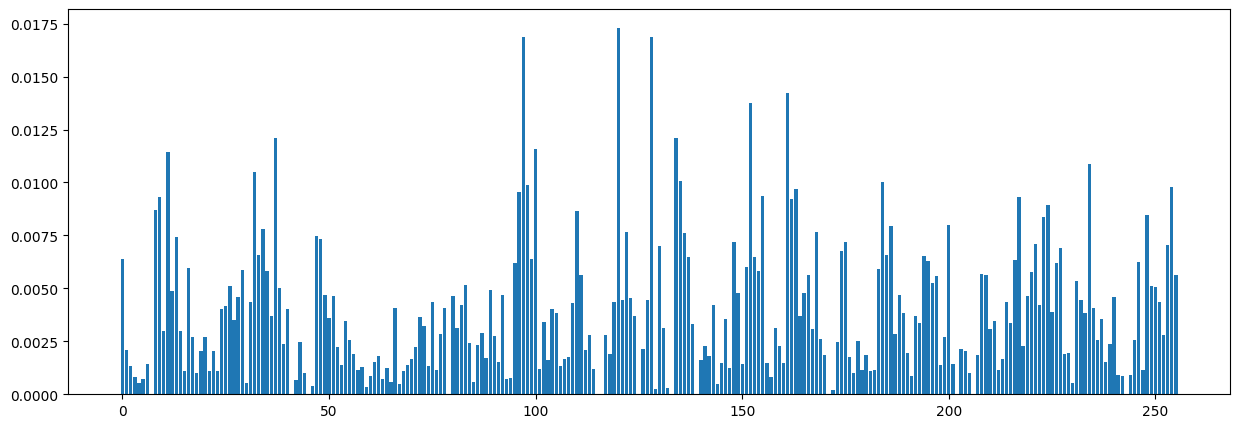

In [6]:
print(dataset.train['hog'][0].shape) 


plt.figure(figsize=(15, 5))
plt.bar(range(256), dataset.train['hog'][0])


In [7]:

# -- Your code here -- #
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# X = matrice des features HoG du train
# shape attendue: (nombre_images, 256)
X = dataset.train['hog']
y = dataset.train['labels']

# 1) Informations générales sur le dataset HoG
print("Shape de X (train HoG):", X.shape)                  # (n_samples, n_features)
print("Type de données:", X.dtype)                         # type numérique (float...)
print("Nombre d'images train:", X.shape[0])
print("Nombre de features HoG par image:", X.shape[1])     # normalement 256



Shape de X (train HoG): (15000, 256)
Type de données: float64
Nombre d'images train: 15000
Nombre de features HoG par image: 256


In [8]:

# 2) Statistiques globales (toutes valeurs confondues)
print("\n=== Statistiques globales ===")
print("Min global:", np.min(X))
print("Max global:", np.max(X))
print("Moyenne globale:", np.mean(X))
print("Écart-type global:", np.std(X))



=== Statistiques globales ===
Min global: 0.0
Max global: 0.2251452001705904
Moyenne globale: 0.003906249999884475
Écart-type global: 0.005722073863398175


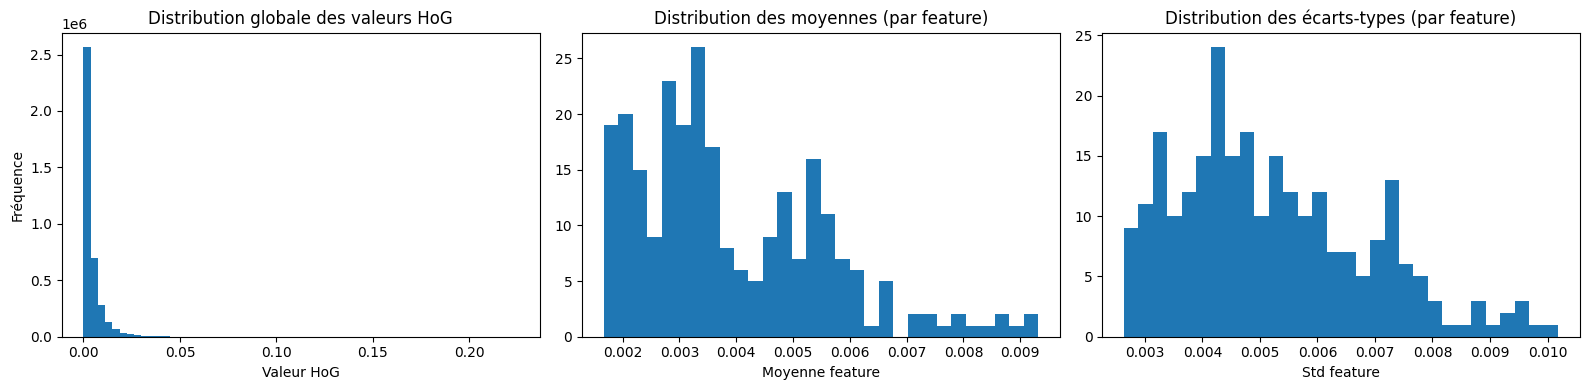

In [9]:

# 6) Visualisations rapides
# Statistiques par feature (sur les 256 dimensions HoG)
feature_mean = X.mean(axis=0)
feature_std = X.std(axis=0)

plt.figure(figsize=(16, 4))

# Histogramme de toutes les valeurs HoG
plt.subplot(1, 3, 1)
plt.hist(X.ravel(), bins=60)
plt.title("Distribution globale des valeurs HoG")
plt.xlabel("Valeur HoG")
plt.ylabel("Fréquence")

# Distribution des moyennes de features
plt.subplot(1,3,2)
plt.hist(feature_mean, bins=30)
plt.title("Distribution des moyennes (par feature)")
plt.xlabel("Moyenne feature")

# Distribution des écarts-types de features
plt.subplot(1, 3, 3)
plt.hist(feature_std, bins=30)
plt.title("Distribution des écarts-types (par feature)")
plt.xlabel("Std feature")

plt.tight_layout()
plt.show()


## Introduction to scikit-learn

[Scikit-learn](https://scikit-learn.org/stable/) is a very well documented machine learning library in Python. It contains many algorithms for [classification](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning), and makes the whole process of building a machine learning pipeline relatively straightforward. There are many examples in the documentation, as well as relatively complete theoretical explanations, so I really encourage you to take the time to read it if some things are not clear.

Let's make a very simple example. We are going to use the [Ridge Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeClassifier.html#sklearn.linear_model.RidgeClassifier), which is a very basic linear model.

In [10]:
from sklearn.linear_model import RidgeClassifier

To use a classifier with scikit-image, we generally have three steps:

* Create an instance of the class of the classifier (here: RidgeClassifier). The constructor will generally contain many arguments that can be modified, and that are explained in the documentation. There will also generally be default values for all of them, so in this simple example we will just use those:

In [11]:
clf = RidgeClassifier() 

* Use the *fit* method with, as arguments, the training data (in our case, the HoG vectors) and the corresponding labels. This will start the main training algorithm, trying to fit the parameters of the classifier with the training data:

In [12]:
clf.fit(dataset.train['hog'], dataset.train['labels'])

/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


RidgeClassifier()

* Use the *predict* method to get the prediction of the classifier on the data given as argument. In this case, we get the predictions on the data that was just used for training. **What kind of performance will that give us?**

In [13]:
pred = clf.predict(dataset.train['hog'])
print(pred.shape)

(15000,)


/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


We can then evaluate those predictions. Scikit-learn provides many different [metrics](https://scikit-learn.org/stable/modules/model_evaluation.html) for evaluating the performances of a classifier. The most simple of those is the accuracy, which is simply the number of correct predictions divided by the total number of predictions:

In [14]:
from sklearn.metrics import accuracy_score

score = accuracy_score(dataset.train['labels'], pred)
print(score)

# Not that it's fairly easy to compute that score "by hand":
T = (pred==dataset.train['labels']).sum()
print(T, len(pred), T/len(pred))

0.7356666666666667
11035 15000 0.7356666666666667


In a multiclass problem, it's often also very useful to look at the [confusion matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html#sklearn.metrics.confusion_matrix), which gives us more information on which classes are often mistaken for each other:

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(dataset.train['labels'], pred)
print(cm)

[[3812  740  448]
 [ 742 3236 1022]
 [ 337  676 3987]]


Note that the rows represent the **true labels** and the columns the **predicted labels**. So this mean that, in this case, out of the 5000 images of class 0 ("Airplane"), 3812 were correctly classified, 740 were classified as "Bird" and 448 as "Horse").

### Quick question

* Modify the code to estimate the **predictive** performance of the algorithm (without using the test set).

In [16]:
# Set the proportion of the dataset to reserve for validation (10% in this case)
p_val = 0.1

# Calculate the exact integer number of validation samples based on the total dataset size
n_val = int(p_val * len(dataset.train['hog']))

# Print the number of validation samples (The image output shows this is 1500)
print(n_val)

# Create the training features (X) by taking all elements up to the last 'n_val' elements
train_X = dataset.train['hog'][:-n_val]
# Create the training labels (Y) to match the training features
train_Y = dataset.train['labels'][:-n_val]

# Create the validation features (X) by taking ONLY the last 'n_val' elements
val_X = dataset.train['hog'][-n_val:]
# Create the validation labels (Y) to match the validation features
val_Y = dataset.train['labels'][-n_val:]

# Print the shapes (dimensions) of the new arrays to verify the split was successful
# The output in the image shows: (13500, 256) (13500,) (1500, 256) (1500,)
print(train_X.shape, train_Y.shape, val_X.shape, val_Y.shape)



1500
(13500, 256) (13500,) (1500, 256) (1500,)


In [17]:

# --- Cell 40: Model Training and Evaluation ---

# Initialize a Ridge Classifier model with a regularization strength (alpha) of 0.1
clf = RidgeClassifier(alpha=0.1)

# Train (fit) the classifier using the training data
clf.fit(train_X, train_Y)

# Use the trained model to make predictions on the unseen validation data
pred = clf.predict(val_X)

# Make predictions on the training data itself to check for underfitting/overfitting
pred_descr = clf.predict(train_X)

# Calculate the accuracy score on the training data (Descriptive accuracy)
score = accuracy_score(train_Y, pred_descr)
# Print the training accuracy formatted to 3 decimal places
print(f"Descriptive: {score:.3f}")

# Calculate the accuracy score on the validation data (Predictive/Generalization accuracy)
score = accuracy_score(val_Y, pred)
# Print the validation accuracy formatted to 3 decimal places
print(f"Predictive: {score:.3f}")

# Generate a confusion matrix to see the breakdown of correct vs. incorrect predictions per class
cm = confusion_matrix(val_Y, pred)
# Print the confusion matrix
print(cm)



Descriptive: 0.756
Predictive: 0.742
[[405  65  42]
 [ 67 330  93]
 [ 34  86 378]]


/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/a

Descriptive: 0.756
C’est l’accuracy sur le jeu d’entraînement (train_X, train_Y).
Donc le modèle classe correctement 75.6% des images qu’il a déjà vues.

Predictive: 0.742
C’est l’accuracy sur le jeu de validation (val_X, val_Y), donc des images non vues pendant l’entraînement.
Donc le modèle généralise à 74.2%.

Différence entre les deux

75.6% (train) vs 74.2% (validation)
L’écart est petit (1.4 points), donc pas de gros surapprentissage ici.
C’est plutôt un comportement sain.<>

## How can we find the "best" algorithm?

What we have shown above served to illustrate how scikit-learn classifiers work, but we now have to build a valid machine learning pipeline to compare the different algorithms that we will use in the next labs.

As we have said earlier, we have already split the dataset into a "training" and a "test" set. It is clear that the final evaluation should take place on the test set.

But in addition to comparing the algorithms between each other, we also have to find the best "hyper-parameters" for each algorithm. For example, in our RidgeClassifier example, there is a regularization parameters, *alpha*, which by default was set to 1.0. Can we improve the performance of the algorithm by modifying this parameter ?

### Side-note: parameter vs hyper-parameter

In general, when talking about machine learning models, **parameters** are what the algorithm learns with the data (if we are for instance learning a linear regression y = ax+b, the "parameters" would be a and b), while **hyper-parameters** are modifiers to the model or to the pipeline (for instance, if we are generalizing to a polynomial regression, the degree of the polynome would be an hyper-parameter).

### Cross-validation

The most common way of finding the best hyper-parameters of a classifier is to use [cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html).

* Using the [cross_val_score](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html#sklearn.model_selection.cross_val_score) method from scikit-learn, find the best *alpha* hyper-parameter for the RidgeClassifier: 

In [18]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


In [19]:

from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# Try several alpha values
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

# 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_alpha = None
best_score = 0

for alpha in alphas:
    clf = RidgeClassifier(alpha=alpha)
    scores = cross_val_score(clf, X, y, cv=cv, scoring="accuracy")
    mean_score = scores.mean()
    
    print(f"alpha = {alpha:>6} | mean accuracy = {mean_score:.4f}")
    
    if mean_score > best_score:
        best_score = mean_score
        best_alpha = alpha

print("\nBest alpha:", best_alpha)
print("Best cross-validation accuracy:", best_score)


alpha =   0.01 | mean accuracy = 0.7459
alpha =    0.1 | mean accuracy = 0.7455
alpha =    1.0 | mean accuracy = 0.7267
alpha =   10.0 | mean accuracy = 0.6909
alpha =  100.0 | mean accuracy = 0.6815

Best alpha: 0.01
Best cross-validation accuracy: 0.7458666666666666


La cross-validation sert a estimer la performance d’un modele sans utiliser le jeu de test final.

Principe rapide :
1. On coupe les donnees d’entrainement en plusieurs parties, par exemple 5.
2. On entraine le modele sur 4 parties.
3. On le teste sur la 5e partie.
4. On recommence en changeant la partie utilisee pour le test.
5. On fait la moyenne des scores.

Pourquoi on fait ca :
- pour avoir une estimation plus fiable des performances
- pour choisir les meilleurs hyper-parametres, comme `alpha`
- pour eviter de juger le modele sur un seul decoupage des donnees

Dans ton cas, on teste plusieurs valeurs de `alpha`, on fait la cross-validation pour chacune, puis on garde celle qui donne la meilleure accuracy moyenne.

### Comparing algorithms

Once you have found the best hyper-parameters for an algorithm, you can re-train the classifier on the whole training set, and finally use the test set to get a "final performance". 

* How can you then decide which of the classifiers is best ?
* How can you decide if the different between two classifiers is significant ?

Try to compare the best RidgeClassifier with the original. Is it significantly better?

In [20]:
print(best_alpha)

0.01


In [21]:
from scipy.stats import ttest_rel

# Compare original RidgeClassifier (alpha=1.0) vs best RidgeClassifier (alpha=best_alpha)

# 1) Cross-validation comparison on training set (same folds -> paired comparison)
orig_clf = RidgeClassifier()  # default alpha=1.0
best_clf = RidgeClassifier(alpha=best_alpha)

orig_scores = cross_val_score(orig_clf, X, y, cv=cv, scoring="accuracy")
best_scores = cross_val_score(best_clf, X, y, cv=cv, scoring="accuracy")

print("CV accuracy (original):", np.round(orig_scores, 4), "mean =", orig_scores.mean())
print("CV accuracy (best)    :", np.round(best_scores, 4), "mean =", best_scores.mean())

diff = best_scores - orig_scores
print("Fold-wise diff (best - original):", np.round(diff, 4), "mean diff =", diff.mean())

# Paired significance test on CV folds
try:
    t_stat, p_val = ttest_rel(best_scores, orig_scores)
    print(f"Paired t-test: t={t_stat:.4f}, p={p_val:.4f}")
    print("Significant improvement on CV?" , "YES" if p_val < 0.05 else "NO")
except Exception:
    print("scipy not available -> skipping paired t-test")

# 2) Final evaluation on test set after retraining on full training set
orig_clf.fit(dataset.train["hog"], dataset.train["labels"])
best_clf.fit(dataset.train["hog"], dataset.train["labels"])

orig_test_pred = orig_clf.predict(dataset.test["hog"])
best_test_pred = best_clf.predict(dataset.test["hog"])

orig_test_acc = accuracy_score(dataset.test["labels"], orig_test_pred)
best_test_acc = accuracy_score(dataset.test["labels"], best_test_pred)

print(f"\nTest accuracy (original): {orig_test_acc:.4f}")
print(f"Test accuracy (best)    : {best_test_acc:.4f}")
print(f"Test delta (best - original): {best_test_acc - orig_test_acc:.4f}")

if best_test_acc > orig_test_acc:
    print("Best RidgeClassifier performs better on the test set.")
elif best_test_acc < orig_test_acc:
    print("Original RidgeClassifier performs better on the test set.")
else:
    print("Both classifiers have the same test accuracy.")

CV accuracy (original): [0.7187 0.7317 0.7357 0.717  0.7303] mean = 0.7266666666666667
CV accuracy (best)    : [0.7323 0.7553 0.755  0.7347 0.752 ] mean = 0.7458666666666666
Fold-wise diff (best - original): [0.0137 0.0237 0.0193 0.0177 0.0217] mean diff = 0.019199999999999995
Paired t-test: t=11.1766, p=0.0004
Significant improvement on CV? YES

Test accuracy (original): 0.7290
Test accuracy (best)    : 0.7433
Test delta (best - original): 0.0143
Best RidgeClassifier performs better on the test set.
